## Uppgift 12

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=12)
plt.title("Beslutsträd för diabetesdata")
plt.show()

## Uppgift 13

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_excel('hr_employee_data.xlsx')

# göra om text till siffror
df_final = pd.get_dummies(df, drop_first=True)

# Definiera X och y
X = df_final.drop('left', axis=1)
y = df_final['left']

# Dela upp i träning och test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Träna modellen
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Utvärdera
y_pred = model.predict(X_test)

print(f"Modellens träffsäkerhet: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetaljerad rapport:")
print(classification_report(y_test, y_pred))

Modellens träffsäkerhet: 0.97

Detaljerad rapport:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2294
           1       0.98      0.91      0.94       706

    accuracy                           0.97      3000
   macro avg       0.98      0.95      0.96      3000
weighted avg       0.98      0.97      0.97      3000



## Uppgift 14

--- Modellutvärdering: Iris ---
Accuracy på valideringsdata: 0.64

Detaljerad rapport:
              precision    recall  f1-score   support

      setosa       0.83      1.00      0.91        10
  versicolor       0.47      0.75      0.58        12
   virginica       0.80      0.29      0.42        14

    accuracy                           0.64        36
   macro avg       0.70      0.68      0.64        36
weighted avg       0.70      0.64      0.61        36



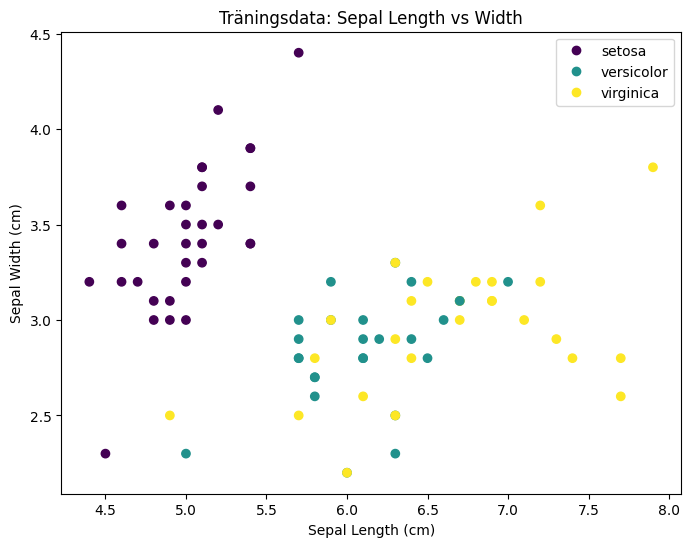

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. LADDA OCH FÖRBERED DATA
iris = load_iris()
X, y = load_iris(return_X_y=True, as_frame=True)

# Vi väljer två variabler för att hålla det enkelt (enligt din startkod)
X_subset = X[['sepal length (cm)', 'sepal width (cm)']]

# 2. DELA UPP DATA (Train, Validation, Test)
# Först dela upp i Training+Validation och Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=40)

# Dela sedan upp Training+Validation i en ren träningsdel och en valideringsdel
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

# 3. TRÄNA MODELLEN (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 4. GÖR FÖRUTSÄGELSER OCH UTVÄRDERA
y_val_pred = knn.predict(X_val)

print("--- Modellutvärdering: Iris ---")
print(f"Accuracy på valideringsdata: {accuracy_score(y_val, y_val_pred):.2f}")
print("\nDetaljerad rapport:")
print(classification_report(y_val, y_val_pred, target_names=iris.target_names))

# 5. VISUALISERING (Scatter plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Träningsdata: Sepal Length vs Width')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()